In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
import random
import time
import pickle as pk

import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import scipy.stats as stats

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

In [2]:
def relu(x):
    return np.maximum(0, x)

In [3]:
def open_datasets(version,
                  time_slice):
    pattern = os.path.join('../../data1', f"*{version}*.nc")
    all_files = sorted(glob.glob(pattern))


    datasets = []
    for fn in all_files[time_slice]:

        ds_i = xr.open_dataset(fn, engine='netcdf4', chunks={'time': 100})
        datasets.append(ds_i)

    """
    concatenate along time dimension
    """
    combined = xr.concat(datasets, dim='time', combine_attrs='override')

    for ds in datasets:
        ds.close()
    
    return combined

In [4]:
version = 'v6-1'
var = 'pr'
time_slice = slice(0,96)

ds = open_datasets(version,
                   time_slice)

/tmp/ipykernel_8491/1213792714.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds_i = xr.open_dataset(fn, engine='netcdf4', chunks={'time': 100})
/tmp/ipykernel_8491/1213792714.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds_i = xr.open_dataset(fn, engine='netcdf4', chunks={'time': 100})
/tmp/ipykernel_8491/1213792714.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  ds_i = xr.open_dataset(fn, engine='netcdf4', chunks={'time': 100})
/tmp/ipykernel_8491/1213792714.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting

In [5]:
coordinates = [
    (100, 200), (100, 400), (400, 100), (400, 500), (600, 200), (700, 500)
]

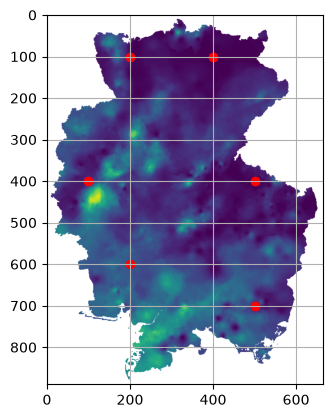

In [6]:
plt.imshow(ds['pr'][0].compute())
plt.scatter([x for y, x in coordinates], [y for y, x in coordinates],  c='red')
plt.grid()
plt.show()

In [7]:
class FiLMBlock(nn.Module):
    def __init__(self, cond_dim, scale_factor, in_ch, out_ch, kernel_size, padding):
        super().__init__()

        self.upscale = nn.Upsample(scale_factor=scale_factor)
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, padding=padding, padding_mode='replicate')
        self.film = nn.Linear(cond_dim, 2 * out_ch)

    def forward(self, x, cond):

        gamma, beta = self.film(cond).chunk(2, dim=-1)
        gamma = gamma[..., None, None]
        beta  = beta[..., None, None]

        return F.gelu(self.conv(self.upscale(x) * gamma + beta))



class PrecipCVAE(nn.Module):
    def __init__(self, out_ch, hid_ch, z_dim, cond_dim, device):
        super().__init__()

        self.z_dim = z_dim
        self.conditionals = cond_dim
        self.device = device
        
        self.init_latent_decoder = nn.Sequential(
            nn.Linear(z_dim, 400),
            nn.GELU(),
            nn.Linear(400, hid_ch*5*5),
            nn.GELU(),
            nn.Unflatten(1, (hid_ch, 5, 5))
        )
        self.cond_decoder = nn.Sequential(
            FiLMBlock(cond_dim, 2, hid_ch, hid_ch, kernel_size=(3,3), padding=1),
            FiLMBlock(cond_dim, 2, hid_ch, hid_ch, kernel_size=(3,3), padding=1),
            FiLMBlock(cond_dim, 1, hid_ch, hid_ch, kernel_size=(3,3), padding=1), 
        )
        self.output = nn.Conv2d(hid_ch, out_ch, kernel_size=(3,3), padding=1, padding_mode='replicate')

    def forward(self, batch_size, conds):
         
        e = (-torch.log(-torch.rand(batch_size, self.z_dim) + 1) - 1).to(self.device) 

        x = self.init_latent_decoder(e)

        conds_expan = conds.expand(batch_size, -1)

        for block in self.cond_decoder:
            x = block(x, conds_expan)

        return self.output(x)


In [8]:
model = PrecipCVAE(out_ch=1, 
                    hid_ch=96, 
                    z_dim = 2,
                    cond_dim = 2,
                    device = 'cpu')
# ../experiments/2026-07-21_10-45-47_src0 2026-03-03_20-01-24_src4
checkpoint = torch.load("2026-03-03_20-01-24_src4/checkpoints/model_final.pth", map_location='cpu')
model.load_state_dict(checkpoint)
model.eval()

PrecipCVAE(
  (init_latent_decoder): Sequential(
    (0): Linear(in_features=2, out_features=400, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=400, out_features=2400, bias=True)
    (3): GELU(approximate='none')
    (4): Unflatten(dim=1, unflattened_size=(96, 5, 5))
  )
  (cond_decoder): Sequential(
    (0): FiLMBlock(
      (upscale): Upsample(scale_factor=2.0, mode='nearest')
      (conv): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=replicate)
      (film): Linear(in_features=2, out_features=192, bias=True)
    )
    (1): FiLMBlock(
      (upscale): Upsample(scale_factor=2.0, mode='nearest')
      (conv): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=replicate)
      (film): Linear(in_features=2, out_features=192, bias=True)
    )
    (2): FiLMBlock(
      (upscale): Upsample(scale_factor=1.0, mode='nearest')
      (conv): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), p

In [9]:
def ks_distance(a, b):

    data = np.sort(np.concatenate([a, b]))

    ecdf_a = np.searchsorted(np.sort(a), data, side='right') / len(a)
    ecdf_b = np.searchsorted(np.sort(b), data, side='right') / len(b)
    
    D = np.sort(np.unique(np.abs(ecdf_a - ecdf_b)))
    D_first = D[-1]
    D_second = D[-2]

    return D_first, D_second, data, ecdf_a, ecdf_b

In [10]:
y_height = 20
x_width = 20
batch_size = 5000
coordinates = [
    (100, 200), (100, 400), (400, 100), (400, 500), (600, 200), (700, 500)
]
num_bins = 200
histograms = {
    'true': {
        'counts': np.zeros((len(coordinates), num_bins-1)),
        'bins': np.zeros((len(coordinates), num_bins)),
    },
    'pred': {
        'counts': np.zeros((len(coordinates), num_bins-1)),
        'bins': np.zeros((len(coordinates), num_bins)),
    }
}
q_samples = [0, 0.5, 0.8, 1]
pic_samples = {
    'true': np.zeros((len(coordinates), len(q_samples), y_height, x_width)),
    'pred': np.zeros((len(coordinates), len(q_samples), y_height, x_width)),
}
metrics = []

In [11]:
for i in range(len(coordinates)):

    y_curr, x_curr = coordinates[i]

    t = slice(0, ds.time.size)
    y = slice(y_curr, y_curr + y_height)
    x = slice(x_curr, x_curr + x_width)

    column = ds['pr'][t, y, x].fillna(0).compute().values

    lat = ds['lat'][y_curr + y_height // 2, x_curr + x_width // 2].compute().values
    lat_mean = ds['lat'].mean().compute().values
    lat_std = ds['lat'].std().compute().values
    lon = ds['lon'][y_curr + y_height // 2, x_curr + x_width // 2].compute().values
    lon_mean = ds['lon'].mean().compute().values
    lon_std = ds['lon'].std().compute().values

    lat = (lat - lat_mean) / lat_std
    lon = (lon - lon_mean) / lon_std
    conds = torch.FloatTensor([lat, lon])

    column_mean = column.mean()
    column_std = column.std()
    #column_param = (column_mean, column_std, column.max())


    preds = []

    with torch.no_grad():
        for _ in range(25):
            pred = model(batch_size, conds) * column_std + column_mean
            preds.append(pred)
        
    preds = torch.concatenate(preds).numpy()
    y = np.round(relu(preds).squeeze(), decimals=1)

    flat_column = column.flatten()
    flat_y = y.flatten()

    bins = np.linspace(0, max(column.max(), y.max()), num_bins)
    (histograms['true']['counts'][i], 
        histograms['true']['bins'][i], 
        _) = plt.hist(flat_column, bins=bins, density=True)
    (histograms['pred']['counts'][i], 
        histograms['pred']['bins'][i], 
        _) = plt.hist(flat_y, bins=bins, density=True)
    plt.close()

    D_f, D_s, x, cdf_true, cdf_pred = ks_distance(flat_column, flat_y)
    metrics.append({
        'id': f"{coordinates[i]}",
        'KS_0': np.round(D_f * 100, 2),
        'KS_1': np.round(D_s * 100, 2),
        'mean_pred': flat_y.mean(),
        'mean_true': flat_column.mean(),
        'var_pred': flat_y.var(),
        'var_true': flat_column.var(),
        'skew_pred': stats.skew(flat_y),
        'skew_true': stats.skew(flat_column),
        'kurt_pred': stats.kurtosis(flat_y),
        'kurt_true': stats.kurtosis(flat_column),
        'rmse': np.sqrt(np.mean((flat_y[ : len(flat_column)] - flat_column)**2))
    })


    for o, quant in enumerate(q_samples):

        column_mm = column.mean(axis=1).mean(axis=1)
        target = np.quantile(column_mm, quant)
        idx = (np.abs(column_mm - target)).argmin()
        pic_samples['true'][i, o] = column[idx]

        y_mm = y.mean(axis=1).mean(axis=1)
        target = np.quantile(y_mm, quant)
        idx = (np.abs(y_mm - target)).argmin()
        pic_samples['pred'][i, o] = y[idx]


    print(f"{coordinates[i]} done")

metrics = pd.DataFrame(metrics).set_index("id")

(100, 200) done
(100, 400) done
(400, 100) done
(400, 500) done
(600, 200) done
(700, 500) done


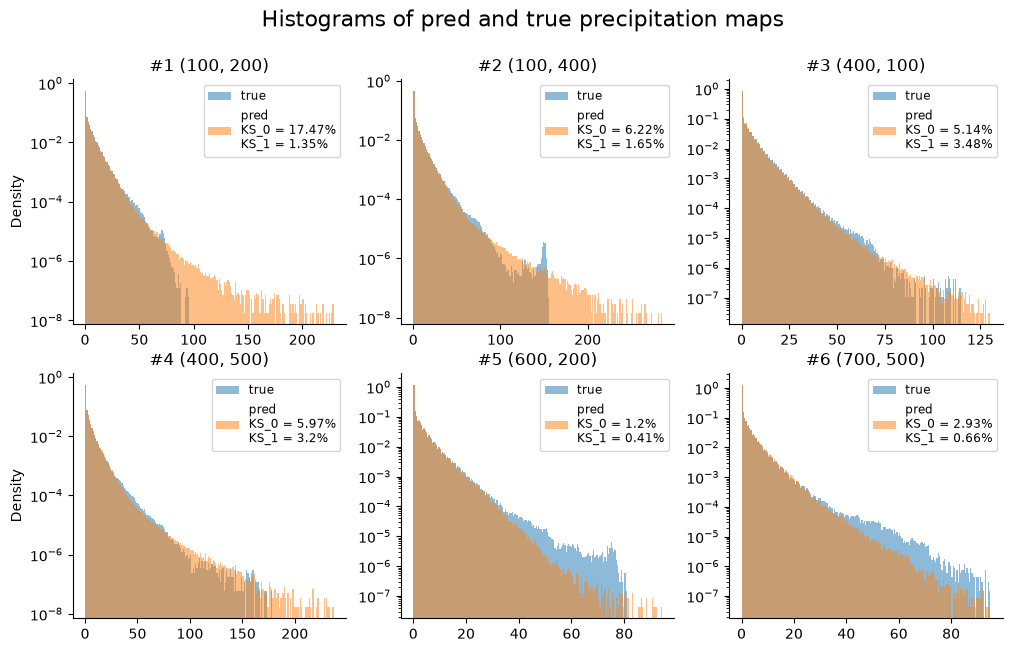

In [12]:
rows = 2
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(12, 7))
fig.suptitle("Histograms of pred and true precipitation maps", fontsize=16)

for i, ax in enumerate(axes.flatten()):

    
    ax.stairs(histograms['true']['counts'][i], 
                histograms['true']['bins'][i], 
                fill=True, alpha=0.5, 
                label=f'true')
    ax.stairs(histograms['pred']['counts'][i], 
                histograms['pred']['bins'][i], 
                fill=True, alpha=0.5,
                label=f'pred\nKS_0 = {metrics.iloc[i]['KS_0']}%\nKS_1 = {metrics.iloc[i]['KS_1']}%')


    ax.set_title(f'#{i+1} {coordinates[i]}')
    ax.set_yscale('log')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize='small')

    if i % cols == 0:
        ax.set_ylabel('Density')

plt.show()

In [13]:
metrics

,KS_0,KS_1,mean_pred,mean_true,var_pred,var_true,skew_pred,skew_true,kurt_pred,kurt_true,rmse
id,,,,,,,,,,,
"(100, 200)",17.47,1.35,2.421507,2.495203,23.201260,24.292812,4.031834,3.686653,31.322502,20.722237,6.841877
"(100, 400)",6.22,1.65,2.580415,2.617135,30.762487,31.866257,4.740249,4.633072,46.940018,39.567211,7.849919
"(400, 100)",5.14,3.48,2.420557,2.476278,21.340176,22.530275,3.627880,3.597578,21.050623,20.620821,6.595209
"(400, 500)",5.97,3.20,2.126276,2.145403,20.702547,21.653172,5.194401,5.022092,58.143982,46.464272,6.476257
"(600, 200)",1.20,0.41,1.828598,1.871737,12.392274,14.035469,3.437972,3.975217,17.139444,26.291996,5.123742
"(700, 500)",2.93,0.66,1.539160,1.533524,11.270198,12.357726,4.225911,5.370932,28.434231,50.252960,4.871452


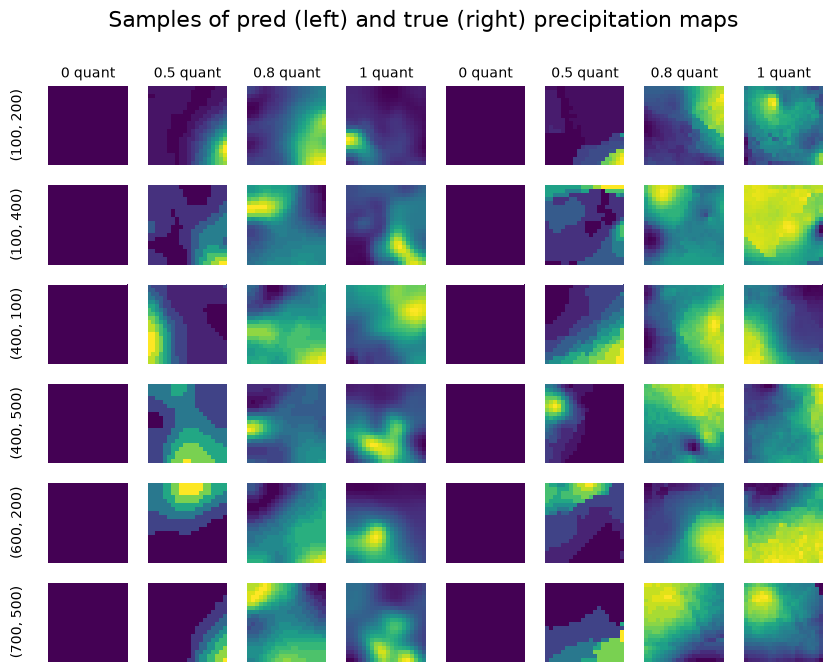

In [14]:
fig = plt.figure(figsize=(10, 8))
fig.suptitle("Samples of pred (left) and true (right) precipitation maps", fontsize=16, y=0.95)

rows = len(coordinates)
cols = 2 * len(q_samples)
grid = ImageGrid(fig, 111, 
                 nrows_ncols=(rows, cols), 
                 axes_pad=0.2) 

for i, ax in enumerate(grid):
    
    r = i // cols
    c = i % cols


    if c < len(q_samples):
        ax.imshow(pic_samples['pred'][r, c % len(q_samples)])

    else:
        ax.imshow(pic_samples['true'][r, c % len(q_samples)])

    ax.axis('off')
    

    if r == 0:
        ax.set_title(f"{q_samples[c % len(q_samples)]} quant", fontsize=10)

    if c == 0:
        ax.text(-0.3, 0.5, f"{coordinates[r]}", transform=ax.transAxes, 
                rotation=90, va='center', ha='right')

plt.show()